# EDA - Eccomerce Analyst

### Overview of Dataset

Objective: วิเคราะห์ภาพกว้างก่อน เพื่อ เข้าใจในชุดข้อมูล และ เข้าใจบริบท และ เพื่อคาดการณ์ในการนําข้อมูล ที่เหลือไปใช้อย่างเหมาะสม

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

## 📊 Executive Summary

This notebook analyzes the e-commerce sales dataset to understand:
- Overall dataset characteristics and data quality
- Revenue distribution and key patterns
- Customer demographics and behavior
- Product performance across categories

**Key Insight:** Top 10% of orders contribute 82.43% of total revenue, indicating strong concentration in high-value transactions.

In [ ]:
# Dataset Summary Statistics
print("=" * 60)
print("📊 E-COMMERCE DATASET SUMMARY".center(60))
print("=" * 60)
print(f"\n📅 Date Range: {df['Order Date'].min()} → {df['Order Date'].max()}")
print(f"📦 Total Records: {len(df):,}")
print(f"👥 Unique Customers: {df['Customer ID'].nunique():,}")
print(f"🛍️  Unique Orders: {df['OrderID'].nunique():,}")
print(f"💰 Total Revenue: ${df['Revenue'].sum():,.2f}")
print(f"📊 Products Sold: {df['Product Name'].nunique()} unique products")
print(f"🏷️  Categories: {', '.join(df['Category'].unique())}")
print(f"🌍 Regions: {', '.join(df['Region'].unique())}")
print("\n" + "=" * 60)

วิเคราะห์กลุ่มลูกค้า ชาย หญิง จํานวนข้อมูลใน Dataset 

In [2]:
# Gender distribution
male = df[df["Gender"] == "Male"]
female = df[df["Gender"] == "Female"]

print("Amount of Male: ", len(male))
print("Amount of Female: ", len(female))

Amount of Male:  524
Amount of Female:  476


In [3]:
df.shape

(1000, 19)

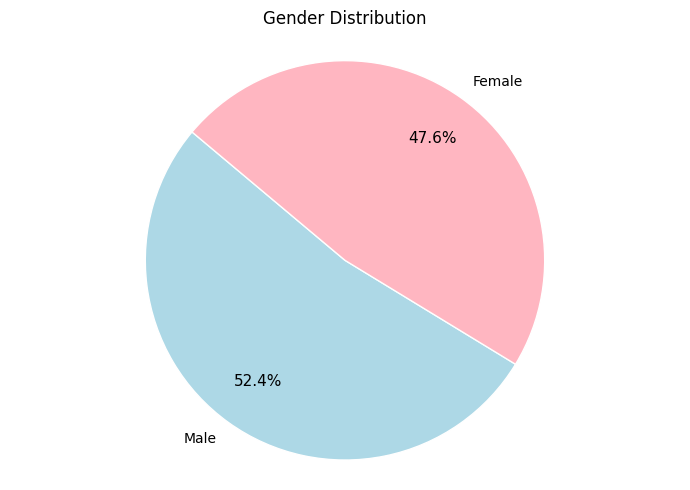

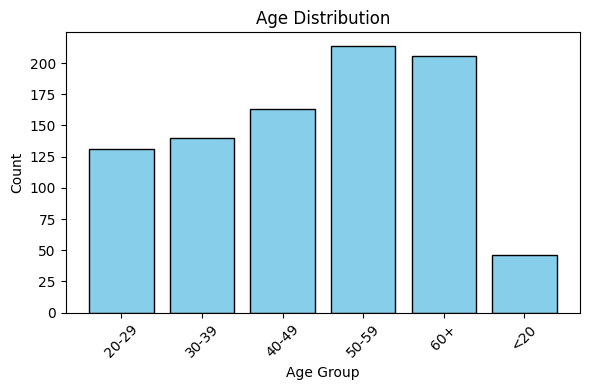

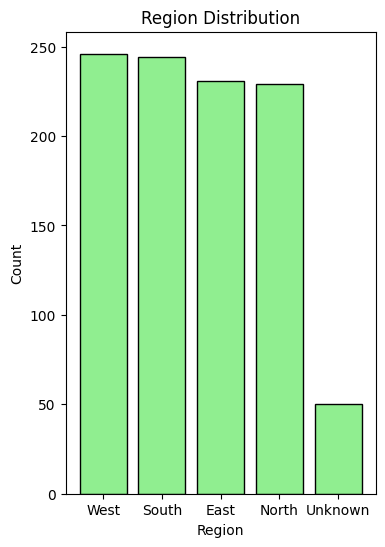

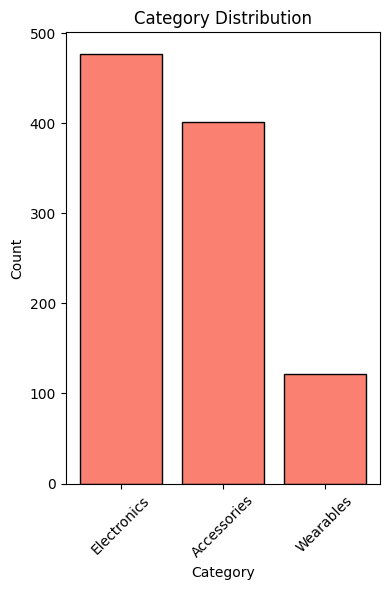

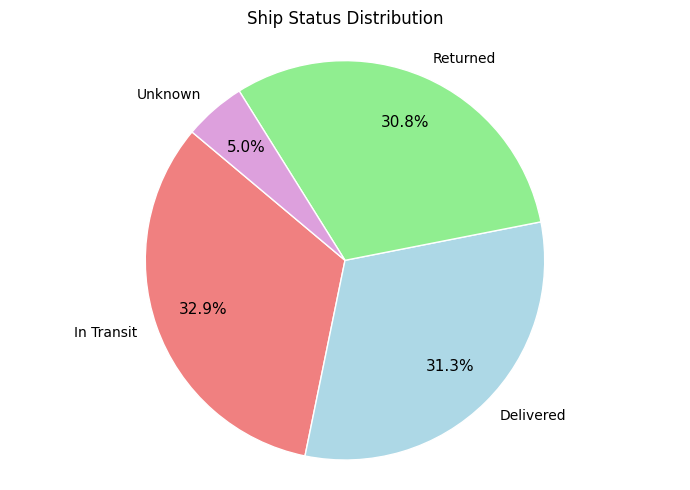

In [4]:
#Gender distribution visualization
gender_counts = df["Gender"].value_counts()
shipping_status_counts = df["Shipping Status"].value_counts()
plt.figure(figsize=(7, 5))
wedges, texts, autotexts = plt.pie(gender_counts.values, labels=gender_counts.index, colors=["lightblue", "lightpink"], autopct="%1.1f%%", startangle=140, pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.setp(autotexts, color="black", fontsize=11)
plt.title("Gender Distribution", pad=12)
plt.axis("equal")
plt.tight_layout()
plt.show()

#Age distribution
plt.figure(figsize=(6, 4))
age_counts = df["AgeGroup"].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Region distribution visualization
region_counts = df["Region"].value_counts()
plt.figure(figsize=(4, 6))
plt.bar(region_counts.index, region_counts.values, color="lightgreen", edgecolor="black")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

#Category distribution visualization
category_counts = df["Category"].value_counts()
plt.figure(figsize=(4, 6))
plt.bar(category_counts.index, category_counts.values, color="salmon", edgecolor="black")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Ship Status distribution visualization
plt.figure(figsize=(7, 5))
wedges, texts, autotexts = plt.pie(shipping_status_counts.values, labels=shipping_status_counts.index, colors=["lightcoral", "lightblue", "lightgreen", "plum"], autopct="%1.1f%%", startangle=140, pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.setp(autotexts, color="black", fontsize=11)
plt.title("Ship Status Distribution", pad=12)
plt.axis("equal")
plt.tight_layout()
plt.show()


In [5]:
df["Shipping Status"].value_counts(normalize=True) * 100

Shipping Status
In Transit    32.9
Delivered     31.3
Returned      30.8
Unknown        5.0
Name: proportion, dtype: float64

- กราฟทั้ง5 ดังกล่าว ผทวิเคราะห์ภาพรวมคล่าวคล่าว คือ อัตรราปริมาณ ลูกค้า ผู้ชาย และ ผู้หญิง, ช่วงอายุลูกค้า, ประเทศ, สถานะการจัดส่ง ล้มเหลว ซึ่งมีกลุ่มเล็กเล็กที่ไม่มีข้อมูล และ ผมได้ เติมค่า unknowไว้ เพราะ บางค่าไม่สามารถ ใส่แทนได้ แลบะ อาจทําไห้การวิเคราะห์คลาดเคลื่อน 

ซึ่งจากข้อมูลแสดงให้เห็นว่า กลุ่มลูกค้ารายใหญ่ คือ กลุ่ม ผู้ชาย 50-59 (แต่ไม่สามารถสรุปได้ว่า เป็นกลุ่มดีที่สุด เพราะ อาจเกิดจากความต่างของขนาดข้อมูล) และ สินค้า ที่ขายดีที่สุดคือประ เภทเครื่องไช้ไฟฟ้า และ สถานะ ปัจจุบันที่มากที่สุดคือ อยู่ระหว่างจัดส่ง

In [6]:
print("All month in Data set:", df["Month_name"].unique())
print("All years in Data set:", df["Year"].unique())

print("\n")

#Count amount of month in each year
print("Number of unique months per year:")
months_per_year = df.groupby("Year")["Month_name"].nunique()
print(months_per_year)

All month in Data set: <StringArray>
[ 'December',     'April',    'August',   'January',   'October',      'June',
  'February', 'September',      'July',       'May',  'November',     'March']
Length: 12, dtype: str
All years in Data set: [2023 2024]


Number of unique months per year:
Year
2023    12
2024     1
Name: Month_name, dtype: int64


จากข้อมูล Data set size มีความต่างกันมาก ไม่สามารถ นําปี ผลรวม 2024 มาเทียบกับ ปี2023 ได้โดยตรง เรา จะสามารถ วิเคราะห์ เฉพาะ เดือนที่มีเเหมือน กัน และ หาค่าเฉลี่ยแทน เท่านั้น และ ต้องคํานึงถึงความเมหาะสม

In [7]:
df.describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee,Year,Day,Revenue
count,900.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000
mean,46.695556,457.703777,3.008000,1346.600000,12.416390,2023.02000,15.31100,407.380000
std,15.011400,537.231434,1.404246,1834.037877,4.412185,0.14007,8.93925,1169.295595
min,18.000000,30.000000,1.000000,30.000000,5.000000,2023.00000,1.00000,0.000000
25%,35.000000,50.000000,2.000000,200.000000,8.560000,2023.00000,7.00000,0.000000
50%,49.000000,200.000000,3.000000,600.000000,12.315000,2023.00000,15.50000,0.000000
75%,59.000000,800.000000,4.000000,1500.000000,16.075000,2023.00000,23.00000,150.000000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000,2024.00000,31.00000,7500.000000


ค่านี้แสดงตัวเลขที่คณิตศาสตร์ที่สําคัญ เพื่อบอก Range, ค่าเฉลี่ย, ค่าสูงสุด, ค่าตํ่าสุด ทําให้เราแยก ออกระหว่างQuantity และ ค่าของตัวแปร

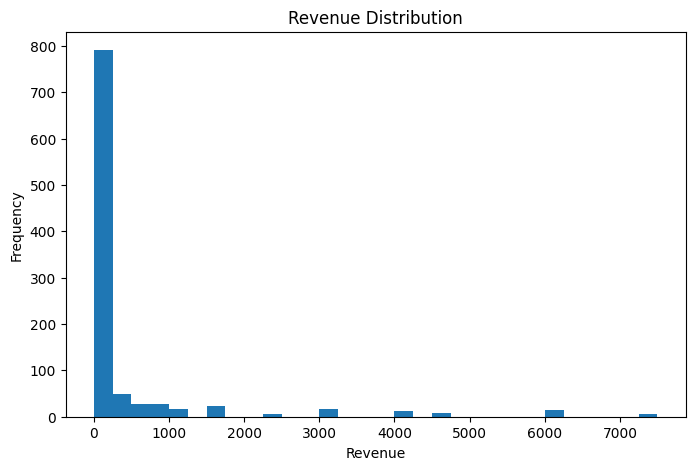

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [9]:
df_sorted = df.sort_values("Revenue", ascending=False)


top_10_percent_count = int(len(df_sorted) * 0.1)
top_10_revenue = df_sorted.head(top_10_percent_count)["Revenue"].sum()

contribution_percent = (top_10_revenue / df["Revenue"].sum()) * 100


print("From Total Products:", len(df_sorted))
print(f"Top 10% of orders contribute {contribution_percent:.2f}% of total revenue that rely on")

From Total Products: 1000
Top 10% of orders contribute 82.43% of total revenue that rely on


- เอารายได้ 10% แรก มา หารด้วยรายได้รวมทั้งหมด และ คูณ 100 เพื่อแปลงเป็น % เพื่อหา เงินที่ 10% แรกทำได้
คิดเป็นกี่เปอร์เซ็นต์ของเงินทั้งหมด เพราะ ตัวกราฟด้านบนแสดงไห้เห็นว่า รายได้จํานวนมาก เป็นรายได้ ตํ่ากว่า 500 ซึ่งเป็นราคาที่กลุ่มลูกค้าส่วนใหญ่ยอมจ่าย และ จากการหานี้แสดงให้เห็นว่า รายได้ ของ บริษัท Eccommerce ทั้งหมด ถึ่งพา กลุ่ม สินค้า ที่ราคาสูง 10อันดับ เป็นหลัก ซึ่งพึ่งพา ถึง 82% ซึ่งถ้ารายได้นี้หายไป จะส่งผลกระทบกับ รายได้หลักของเรามาก 